In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, callbacks, utils
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
import xgboost as xgb

In [14]:
df=pd.read_csv("combined_air_quality_modified.csv")
df = df.dropna(subset=['status'])
df.head()

,country,date,county,sitename,aqi,status,pm2.5,pm10,no,no2,nox,co,so2,o3,siteid
0,Philippines,2014-01-01 00:00:00,NCR,Manila,118.0,Unhealthy for Sensitive Groups,42.450712,105.388892,18.993939,68.680839,46.467632,1.180798,23.094493,12.319120,NaN
1,Philippines,2014-02-01 00:00:00,NCR,Manila,95.0,Moderate,32.926035,77.352669,22.808572,57.520162,42.574229,0.793464,19.536258,44.687065,NaN
2,Philippines,2014-03-01 00:00:00,NCR,Manila,124.0,Unhealthy for Sensitive Groups,44.715328,99.910623,34.325038,54.807419,47.240203,1.000999,26.546239,26.985845,NaN
3,Philippines,2014-04-01 00:00:00,NCR,Manila,152.0,Unhealthy for Sensitive Groups,57.845448,138.179877,20.041346,80.667124,53.375489,1.428835,34.518627,48.524207,NaN
4,Philippines,2014-05-01 00:00:00,NCR,Manila,92.0,Moderate,31.487699,70.390261,22.100780,56.562426,41.691499,1.120790,17.809835,51.075438,NaN


In [15]:
features = ['so2', 'co', 'o3', 'pm10', 'pm2.5', 'no2', 'nox', 'no']
X = df[features]
y = df['status']

In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())
num_classes = len(le.classes_)
#y_encoded =utils.to_categorical(y_encoded, num_classes=num_classes)

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,shuffle=True)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(8,)), 
    
    
    # first Dense layer
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Second Dense layer
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # third Dense layer
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # third Dense layer
    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [20]:
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_GXB_classifier.keras', monitor='val_accuracy', save_best_only=True),
    reduce_lr
]

In [21]:
model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=100, batch_size=128,validation_split=0.2,callbacks=my_callbacks,shuffle=True)

Epoch 1/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8854 - loss: 0.3708 - val_accuracy: 0.9222 - val_loss: 0.1982 - learning_rate: 5.0000e-04
Epoch 2/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9195 - loss: 0.2207 - val_accuracy: 0.9318 - val_loss: 0.1663 - learning_rate: 5.0000e-04
Epoch 3/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9232 - loss: 0.1974 - val_accuracy: 0.9393 - val_loss: 0.1559 - learning_rate: 5.0000e-04
Epoch 4/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9265 - loss: 0.1869 - val_accuracy: 0.9357 - val_loss: 0.1569 - learning_rate: 5.0000e-04
Epoch 5/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9282 - loss: 0.1805 - val_accuracy: 0.9412 - val_loss: 0.1486 - learning_rate: 5.0000e-04
Epoch 6/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9298 - loss: 0.1754 - val_accuracy: 0.9383 - val_loss: 0.1509 - learning_rate: 5.0000e-04
Epoch 7/100
728/728 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc

In [30]:
best_model=tf.keras.models.load_model("best_model_GXB_classifier.keras")



# 1. Generate soft pseudo-labels from your trained Normal NN teacher
nn_predictions = best_model.predict(X_train_scaled)
y_pseudo_train = np.argmax(nn_predictions, axis=1)

# 2. Train the XGBoost Classifier using the NN's pseudo-labels
# 'multi:softprob' or 'multi:softmax' handles multiclass tasks automatically
xgb_distilled = xgb.XGBClassifier(
    colsample_bytree=1.0,
    min_child_weight=0.3,
    subsample=0.7,
    n_estimators=300,
    max_depth=7,
    learning_rate=0.15,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
xgb_distilled.fit(X_train_scaled, y_pseudo_train)

# 3. Scale and prepare your raw test subset
X_test_scaled = scaler.transform(X_test)

# 4. Predict using the distilled XGBoost model
y_pred_xgb = xgb_distilled.predict(X_test_scaled)

print("--- Distilled XGBoost Performance (Normal NN Teacher) ---")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_, zero_division=0))

3639/3639 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
--- Distilled XGBoost Performance (Normal NN Teacher) ---
                                precision    recall  f1-score   support

                          Good       0.95      0.99      0.97     24149
                      Moderate       0.91      0.74      0.82      4623
Unhealthy for Sensitive Groups       0.97      0.91      0.94       337

                      accuracy                           0.95     29109
                     macro avg       0.94      0.88      0.91     29109
                  weighted avg       0.95      0.95      0.94     29109



In [31]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# Convert y_test from a 2D one-hot matrix to 1D integer labels
y_test_ground_truth = y_test

# Fix: Changed y_pred to y_pred_rf
accuracy = accuracy_score(y_test_ground_truth, y_pred_xgb)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_ground_truth, y_pred_xgb, average='weighted')

print("--- Overall Categorical Performance (Global) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

--- Overall Categorical Performance (Global) ---
Accuracy:  94.71%
Precision: 0.9459
Recall:    0.9471
F1-Score:  0.9450


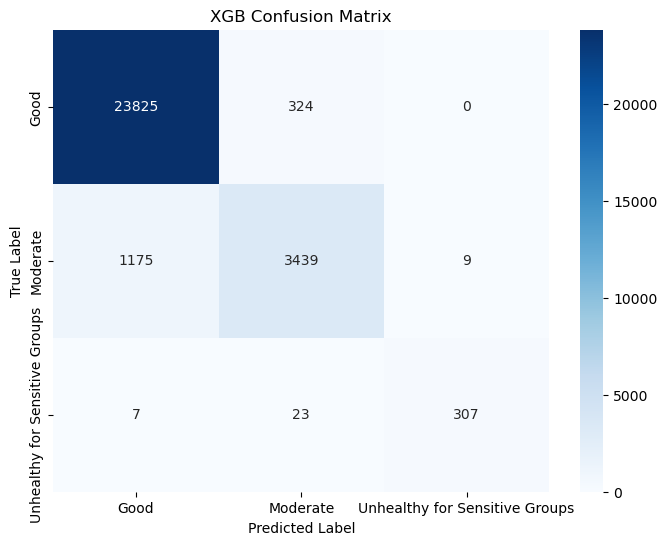

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Convert y_test from one-hot encoding to integer labels
y_test_labels = y_test

# 2. Generate the confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_xgb)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGB Confusion Matrix')
plt.savefig('PhT_class_fit_perf.png')
plt.show()

In [25]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. Define the parameter space distribution
param_distributions = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

# 2. Initialize the baseline model
xgb_clf = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss')

# 3. Set up Randomized Search (n_iter=10 trains 10 random combinations)
clf_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_distributions,
    n_iter=10, 
    cv=3, 
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# 4. Run the search on the Teacher's pseudo-labels
print("Searching for the optimal classifier parameters...")
clf_search.fit(X_train_scaled, y_pseudo_train)

# 5. Extract and evaluate the best setup
print("Best Parameters Found:", clf_search.best_params_)
best_xgb_clf = clf_search.best_estimator_

y_pred_xgb = best_xgb_clf.predict(X_test_scaled)

Searching for the optimal classifier parameters...
Best Parameters Found: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.15, 'colsample_bytree': 1.0}
